# Evaluación Parcial N°2 - Redes Neuronales Convolucionales (CNN)

**Asignatura:** Deep Learning (DLY0100)
**Estudiante:** Álvaro Flores
**Sede:** Duoc UC Puerto Montt
**Fecha:** Mayo 2026

## Objetivo

Implementar una red neuronal convolucional (CNN) para clasificar imágenes de 18 personajes de Los Simpsons, aplicando conceptos de capas convolucionales, pooling, regularización y comparando resultados con la MLP de la evaluación anterior y ResNet.



**Prompt:** Quiero importar todas las librerías necesarias para trabajar con redes neuronales convolucionales (CNN) en TensorFlow/Keras, procesamiento de imágenes con OpenCV, visualización con matplotlib y métricas de evaluación con sklearn.

In [ ]:
# ============================================
# Importar librerías necesarias
# ============================================
from google.colab.patches import cv2_imshow
import cv2  # Procesamiento de imágenes
import os  # Manejo de rutas y archivos
import numpy as np  # Manejo de arrays
import keras  # Framework de deep learning
import glob  # Búsqueda de archivos
import matplotlib.pyplot as plt  # Gráficos
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential  # Modelo secuencial
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D  # Capas para CNN
from keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ Librerías importadas correctamente")
print(f"TensorFlow version: {tf.__version__}")

✅ Librerías importadas correctamente
TensorFlow version: 2.20.0


**Prompt:** Los datos están en mi Google Drive. Quiero montar Drive, copiar los archivos y descomprimirlos.

In [ ]:
# ============================================
# Montar Google Drive y copiar los datos
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import tarfile
import os

os.makedirs("/root/.keras/datasets/", exist_ok=True)

# Copiar archivos desde Drive
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_train.tar.gz" "/root/.keras/datasets/simpsons_train.tar.gz"
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_test.tar.gz" "/root/.keras/datasets/simpsons_test.tar.gz"

# Descomprimir
!tar -xzf "/root/.keras/datasets/simpsons_train.tar.gz" -C "/root/.keras/datasets/"
!tar -xzf "/root/.keras/datasets/simpsons_test.tar.gz" -C "/root/.keras/datasets/"

print("✅ Datos copiados y descomprimidos")

Mounted at /content/drive
✅ Datos copiados y descomprimidos


**Prompt:** Quiero verificar que los datos se descomprimieron correctamente. Muéstrame las carpetas de personajes en entrenamiento y algunas imágenes de prueba.

In [ ]:
# ============================================
# Verificar que los datos se cargaron correctamente
# ============================================
print("Carpetas de entrenamiento (personajes):")
!ls /root/.keras/datasets/simpsons/ | head -10

print("\nPrimeras imágenes de prueba:")
!ls /root/.keras/datasets/simpsons_testset/ | head -10

Carpetas de entrenamiento (personajes):
abraham_grampa_simpson
agnes_skinner
apu_nahasapeemapetilon
barney_gumble
bart_simpson
bumblebee_man
carl_carlson
charles_montgomery_burns
chief_wiggum
cletus_spuckler

Primeras imágenes de prueba:
abraham_grampa_simpson_0.jpg
abraham_grampa_simpson_10.jpg
abraham_grampa_simpson_11.jpg
abraham_grampa_simpson_12.jpg
abraham_grampa_simpson_13.jpg
abraham_grampa_simpson_14.jpg
abraham_grampa_simpson_15.jpg
abraham_grampa_simpson_16.jpg
abraham_grampa_simpson_17.jpg
abraham_grampa_simpson_18.jpg


## Análisis del dataset

Cada personaje tiene su propia carpeta con imágenes. La clase con más imágenes es homer_simpson (2246) y la que menos tiene es nelson_muntz (358). Esto puede afectar el rendimiento en clases con pocos ejemplos.

**Prompt:** Quiero definir el mapeo de personajes (números del 0 al 17) y las funciones para cargar las imágenes de entrenamiento y prueba. También quiero definir el tamaño de imagen (64x64) que usaremos para la CNN.

In [ ]:
# ============================================
# Definir mapeo de personajes y funciones de carga
# ============================================

# Mapeo: cada número (0-17) corresponde a un personaje
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Tamaño al que redimensionaremos todas las imágenes
IMG_SIZE = 64

def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
            print("Leyendo {} imágenes de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image, (IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

def load_test_set(dirname, map_characters, verbose=True):
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

print("✅ Funciones definidas")

✅ Funciones definidas


**Prompt:** Quiero ejecutar la carga de datos, barajarlos (mezclarlos) y normalizar los píxeles dividiendo por 255.

In [ ]:
# ============================================
# Ejecutar la carga de datos
# ============================================

DATASET_TRAIN_PATH = "/root/.keras/datasets/simpsons"
DATASET_TEST_PATH = "/root/.keras/datasets/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)

# Barajar
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Normalizar
X = X / 255.0
X_t = X_t / 255.0

print(f"\n✅ Shape entrenamiento: {X.shape}")
print(f"✅ Shape prueba: {X_t.shape}")

Leyendo 913 imágenes de abraham_grampa_simpson
Leyendo 623 imágenes de apu_nahasapeemapetilon
Leyendo 1342 imágenes de bart_simpson
Leyendo 1193 imágenes de charles_montgomery_burns
Leyendo 986 imágenes de chief_wiggum
Leyendo 469 imágenes de comic_book_guy
Leyendo 457 imágenes de edna_krabappel
Leyendo 2246 imágenes de homer_simpson
Leyendo 498 imágenes de kent_brockman
Leyendo 1206 imágenes de krusty_the_clown
Leyendo 1354 imágenes de lisa_simpson
Leyendo 1291 imágenes de marge_simpson
Leyendo 1079 imágenes de milhouse_van_houten
Leyendo 1452 imágenes de moe_szyslak
Leyendo 1454 imágenes de ned_flanders
Leyendo 358 imágenes de nelson_muntz
Leyendo 1194 imágenes de principal_skinner
Leyendo 877 imágenes de sideshow_bob
Leídas 890 imágenes de test

✅ Shape entrenamiento: (18992, 64, 64, 3)
✅ Shape prueba: (890, 64, 64, 3)


**Prompt:** Quiero dividir los datos en entrenamiento (80%) y validación (20%). Usar stratify para mantener la misma proporción de personajes en ambos conjuntos.

In [ ]:
# ============================================
# Dividir datos en entrenamiento y validación (80/20)
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Prueba: {X_t.shape}")

Entrenamiento: (15193, 64, 64, 3)
Validación: (3799, 64, 64, 3)
Prueba: (890, 64, 64, 3)


**Prompt:** Quiero mostrar una imagen de ejemplo de cada uno de los 18 personajes para visualizar cómo se ven después del redimensionamiento a 64x64.

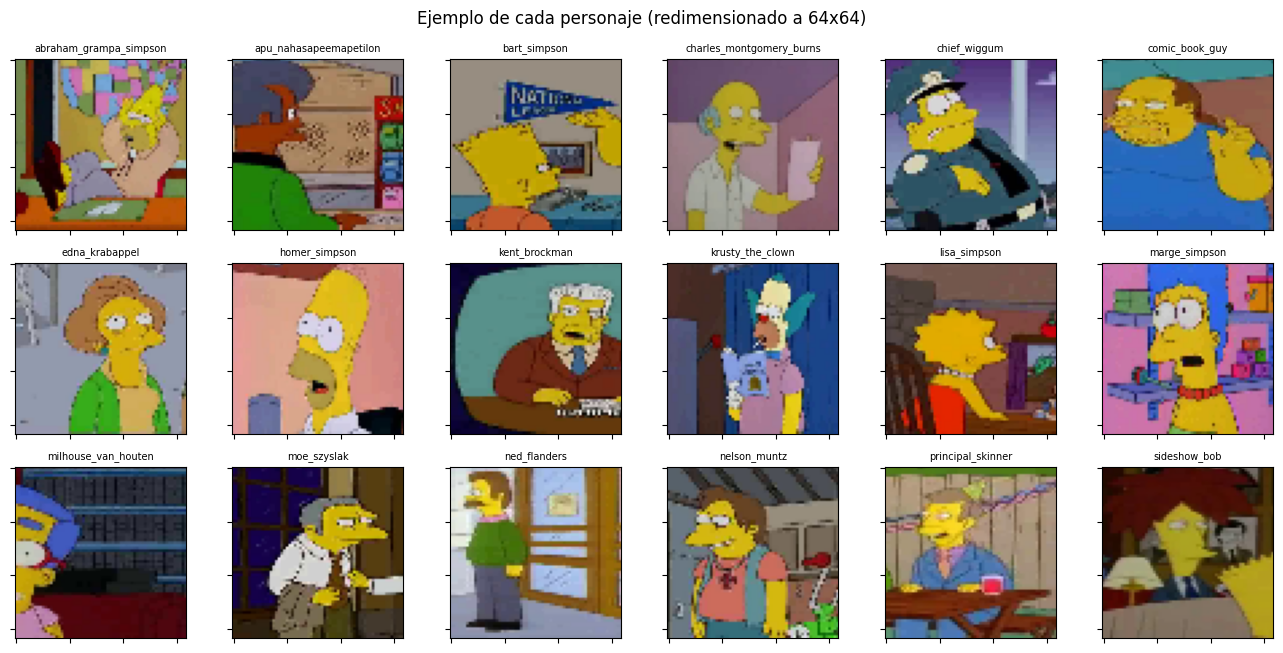

In [ ]:
# ============================================
# Mostrar una imagen de ejemplo por cada personaje
# ============================================

nombres = list(MAP_CHARACTERS.values())

h = 3
w = 6

fig, axs = plt.subplots(h, w, figsize=(2.2*w, 2.2*h))

for i in range(h):
    for j in range(w):
        idx_personaje = i * w + j
        if idx_personaje < len(nombres):
            personaje = nombres[idx_personaje]
            ruta_personaje = os.path.join(DATASET_TRAIN_PATH, personaje)
            imagenes = [f for f in os.listdir(ruta_personaje) if f.endswith('jpg')]
            imagen_aleatoria = np.random.choice(imagenes)

            img = cv2.imread(os.path.join(ruta_personaje, imagen_aleatoria))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axs[i, j].set_title(personaje, fontsize=7)
            axs[i, j].grid(False)
            axs[i, j].set_xticklabels([])
            axs[i, j].set_yticklabels([])
            axs[i, j].imshow(img)
        else:
            axs[i, j].axis('off')

plt.suptitle('Ejemplo de cada personaje (redimensionado a 64x64)', fontsize=12)
plt.tight_layout()
plt.show()

### ¿Por qué 64x64?

- 32x32: perderíamos detalles importantes (ojos, boca, rasgos)
- 128x128: más memoria y tiempo de entrenamiento
- 64x64: balance óptimo entre calidad y eficiencia computacional

El cálculo del tamaño de entrada es 64 x 64 x 3 (canales RGB) = 12,288 neuronas en la capa de entrada si fuera MLP. Para CNN, usamos capas convolucionales.

**Prompt:** Quiero crear un modelo CNN base para clasificar los 18 personajes. Debe tener capas Conv2D, MaxPooling2D, Flatten y Dense. Usaré ReLU como activación, Softmax en la salida, optimizador SGD con learning rate 0.01 y sparse_categorical_crossentropy como función de pérdida.

In [ ]:
# ============================================
# Crear modelo CNN base
# ============================================

np.random.seed(30)
tf.random.set_seed(30)

cnn_base = Sequential()

cnn_base.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
cnn_base.add(MaxPooling2D((2, 2)))

cnn_base.add(Conv2D(64, (3, 3), activation='relu'))
cnn_base.add(MaxPooling2D((2, 2)))

cnn_base.add(Conv2D(128, (3, 3), activation='relu'))
cnn_base.add(MaxPooling2D((2, 2)))

cnn_base.add(Flatten())

cnn_base.add(Dense(256, activation='relu'))
cnn_base.add(Dense(128, activation='relu'))
cnn_base.add(Dense(64, activation='relu'))

cnn_base.add(Dense(18, activation='softmax'))

cnn_base.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo CNN Base - Resumen:")
cnn_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo CNN Base - Resumen:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,474 (5.02 MB)

 Trainable params: 1,315,474 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

**Prompt:** Quiero entrenar el modelo CNN base durante 30 épocas con batch size de 64, usando validación. Al final, evaluar en el conjunto de prueba.

In [ ]:
# ============================================
# Entrenar modelo CNN base
# ============================================

history_cnn_base = cnn_base.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_cnn_base, test_acc_cnn_base = cnn_base.evaluate(X_t, y_t)
print(f"\n✅ Precisión del CNN Base en prueba: {test_acc_cnn_base:.4f} ({test_acc_cnn_base*100:.1f}%)")

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.1162 - loss: 2.8339 - val_accuracy: 0.1182 - val_loss: 2.7785
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.1378 - loss: 2.7326 - val_accuracy: 0.1843 - val_loss: 2.6684
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1981 - loss: 2.5914 - val_accuracy: 0.2224 - val_loss: 2.5109
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2581 - loss: 2.4219 - val_accuracy: 0.2785 - val_loss: 2.3680
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3075 - loss: 2.2657 - val_accuracy: 0.3175 - val_loss: 2.2247
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3552 - loss: 2.1179 - val_accuracy: 0.3685 - val_loss: 2.0633
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4017 - loss: 1.9804 - val_accuracy: 0.3946 - val_loss: 1.9764
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4472 - loss: 1.8503 - val_ac

**Prompt:** Quiero graficar la pérdida (loss) y la precisión (accuracy) del entrenamiento y validación del modelo CNN base para analizar si hay overfitting.

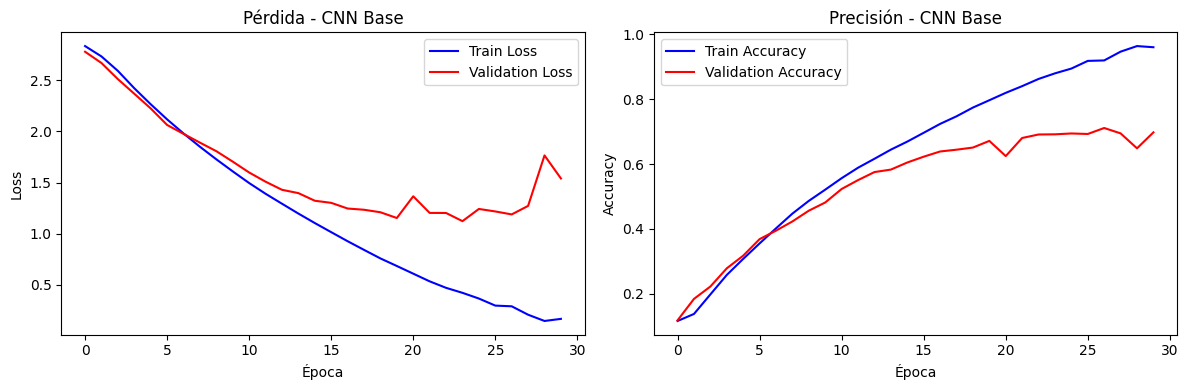


ANÁLISIS DE OVERFITTING - CNN BASE
Loss final - Train: 0.1690, Validation: 1.5407
Accuracy final - Train: 0.9599, Validation: 0.6976
Diferencia de loss: +1.3717
Diferencia de accuracy: +0.2624

⚠️ Se detecta overfitting. La red está memorizando los datos de entrenamiento.


In [ ]:
# ============================================
# Graficar pérdida y precisión del modelo CNN base
# ============================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn_base.history['loss'], label='Train Loss', color='blue')
plt.plot(history_cnn_base.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - CNN Base')

plt.subplot(1, 2, 2)
plt.plot(history_cnn_base.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_cnn_base.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - CNN Base')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ANÁLISIS DE OVERFITTING - CNN BASE")
print("="*50)

loss_train_final = history_cnn_base.history['loss'][-1]
loss_val_final = history_cnn_base.history['val_loss'][-1]
acc_train_final = history_cnn_base.history['accuracy'][-1]
acc_val_final = history_cnn_base.history['val_accuracy'][-1]

print(f"Loss final - Train: {loss_train_final:.4f}, Validation: {loss_val_final:.4f}")
print(f"Accuracy final - Train: {acc_train_final:.4f}, Validation: {acc_val_final:.4f}")
print(f"Diferencia de loss: {loss_val_final - loss_train_final:+.4f}")
print(f"Diferencia de accuracy: {acc_train_final - acc_val_final:+.4f}")

if loss_val_final > loss_train_final * 1.2:
    print("\n⚠️ Se detecta overfitting. La red está memorizando los datos de entrenamiento.")
else:
    print("\n✅ No hay overfitting severo.")

**Prompt:** Quiero probar Dropout como técnica de regularización para reducir el overfitting. Añadiré Dropout después de cada capa convolucional y después de las capas densas.

In [ ]:
# ============================================
# Modelo CNN con Dropout
# ============================================

np.random.seed(30)
tf.random.set_seed(30)

cnn_dropout = Sequential()

cnn_dropout.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
cnn_dropout.add(MaxPooling2D((2, 2)))
cnn_dropout.add(Dropout(0.25))

cnn_dropout.add(Conv2D(64, (3, 3), activation='relu'))
cnn_dropout.add(MaxPooling2D((2, 2)))
cnn_dropout.add(Dropout(0.25))

cnn_dropout.add(Conv2D(128, (3, 3), activation='relu'))
cnn_dropout.add(MaxPooling2D((2, 2)))
cnn_dropout.add(Dropout(0.25))

cnn_dropout.add(Flatten())

cnn_dropout.add(Dense(256, activation='relu'))
cnn_dropout.add(Dropout(0.5))
cnn_dropout.add(Dense(128, activation='relu'))
cnn_dropout.add(Dropout(0.5))
cnn_dropout.add(Dense(64, activation='relu'))

cnn_dropout.add(Dense(18, activation='softmax'))

cnn_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo CNN con Dropout - Resumen:")
cnn_dropout.summary()

Modelo CNN con Dropout - Resumen:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,474 (5.02 MB)

 Trainable params: 1,315,474 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

**Prompt:** Entrenar el modelo CNN con Dropout durante 30 épocas y evaluar en prueba.

In [ ]:
# ============================================
# Entrenar modelo CNN con Dropout
# ============================================

history_cnn_dropout = cnn_dropout.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_dropout, test_acc_dropout = cnn_dropout.evaluate(X_t, y_t)
print(f"\n✅ Precisión del CNN con Dropout en prueba: {test_acc_dropout:.4f} ({test_acc_dropout*100:.1f}%)")

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.0893 - loss: 2.8567 - val_accuracy: 0.1182 - val_loss: 2.8420
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1068 - loss: 2.8184 - val_accuracy: 0.1182 - val_loss: 2.8212
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1157 - loss: 2.7985 - val_accuracy: 0.1182 - val_loss: 2.8072
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1172 - loss: 2.7814 - val_accuracy: 0.1182 - val_loss: 2.7841
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1210 - loss: 2.7556 - val_accuracy: 0.1382 - val_loss: 2.7396
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1428 - loss: 2.7050 - val_accuracy: 0.2130 - val_loss: 2.6581
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1672 - loss: 2.6433 - val_accuracy: 0.2337 - val_loss: 2.5890
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1894 - loss: 2.5856 - val_acc

**Prompt:** Probar BatchNormalization después de cada capa convolucional y después de las capas densas para estabilizar el entrenamiento y reducir overfitting.

In [ ]:
# ============================================
# Modelo CNN con BatchNormalization
# ============================================

np.random.seed(30)
tf.random.set_seed(30)

cnn_bn = Sequential()

cnn_bn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
cnn_bn.add(BatchNormalization())
cnn_bn.add(MaxPooling2D((2, 2)))

cnn_bn.add(Conv2D(64, (3, 3), activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(MaxPooling2D((2, 2)))

cnn_bn.add(Conv2D(128, (3, 3), activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(MaxPooling2D((2, 2)))

cnn_bn.add(Flatten())

cnn_bn.add(Dense(256, activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(Dense(128, activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(Dense(64, activation='relu'))

cnn_bn.add(Dense(18, activation='softmax'))

cnn_bn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo CNN con BatchNormalization - Resumen:")
cnn_bn.summary()

Modelo CNN con BatchNormalization - Resumen:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,906 (5.03 MB)

 Trainable params: 1,316,690 (5.02 MB)

 Non-trainable params: 1,216 (4.75 KB)

**Prompt:** Entrenar el modelo CNN con BatchNormalization durante 30 épocas y evaluar en prueba.

In [ ]:
# ============================================
# Entrenar modelo CNN con BatchNormalization
# ============================================

history_cnn_bn = cnn_bn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_bn, test_acc_bn = cnn_bn.evaluate(X_t, y_t)
print(f"\n✅ Precisión del CNN con BatchNormalization en prueba: {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.3612 - loss: 2.1997 - val_accuracy: 0.1937 - val_loss: 2.7124
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6076 - loss: 1.3843 - val_accuracy: 0.4830 - val_loss: 1.7354
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7143 - loss: 1.0291 - val_accuracy: 0.6512 - val_loss: 1.2396
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7972 - loss: 0.7754 - val_accuracy: 0.6702 - val_loss: 1.1401
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8620 - loss: 0.5729 - val_accuracy: 0.6910 - val_loss: 1.0729
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9137 - loss: 0.4133 - val_accuracy: 0.6931 - val_loss: 1.0550
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9497 - loss: 0.2908 - val_accuracy: 0.7162 - val_loss: 1.0042
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9745 - loss: 0.2008 - val_acc

**Prompt:** Quiero graficar la pérdida y precisión del modelo con BatchNormalization para analizar su convergencia y comparar con el modelo base.

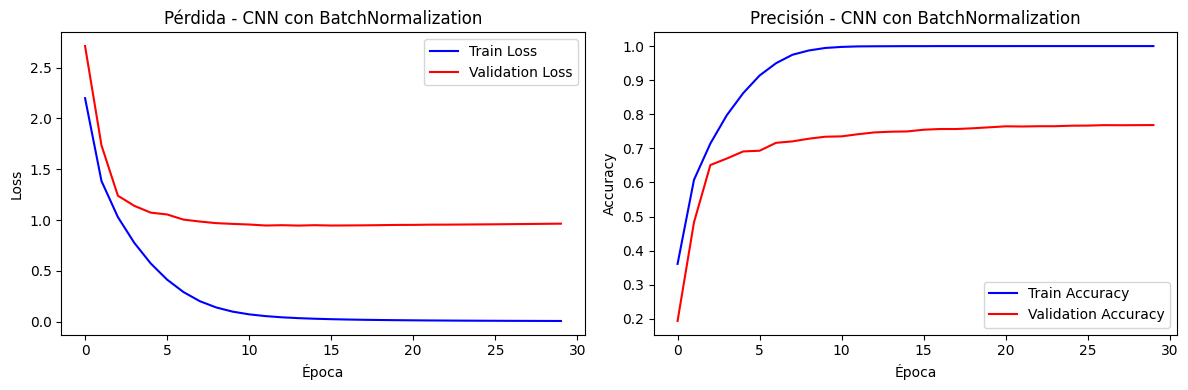


COMPARACIÓN ENTRE MODELOS CNN
Modelo                              Precisión prueba
------------------------------------------------------------
CNN Base                            0.8483 (84.8%)
CNN + Dropout                       0.4742 (47.4%)
CNN + BatchNormalization (MEJOR)    0.9360 (93.6%)


In [ ]:
# ============================================
# Graficar pérdida y precisión - CNN con BatchNormalization
# ============================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn_bn.history['loss'], label='Train Loss', color='blue')
plt.plot(history_cnn_bn.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - CNN con BatchNormalization')

plt.subplot(1, 2, 2)
plt.plot(history_cnn_bn.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_cnn_bn.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - CNN con BatchNormalization')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMPARACIÓN ENTRE MODELOS CNN")
print("="*60)
print(f"{'Modelo':<35} {'Precisión prueba':<15}")
print("-"*60)
print(f"{'CNN Base':<35} {test_acc_cnn_base:.4f} ({test_acc_cnn_base*100:.1f}%)")
print(f"{'CNN + Dropout':<35} {test_acc_dropout:.4f} ({test_acc_dropout*100:.1f}%)")
print(f"{'CNN + BatchNormalization (MEJOR)':<35} {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")
print("="*60)

**Prompt:** Quiero ver las métricas detalladas (precision, recall, f1-score) por cada personaje para el mejor modelo (CNN con BatchNormalization).

In [ ]:
# ============================================
# Métricas detalladas del mejor modelo (CNN + BatchNormalization)
# ============================================

y_pred_bn = cnn_bn.predict(X_t)
y_pred_classes_bn = np.argmax(y_pred_bn, axis=1)

print("\n" + "="*65)
print("MÉTRICAS POR CLASE - CNN CON BATCHNORMALIZATION (MEJOR MODELO)")
print("="*65)
print(classification_report(y_t, y_pred_classes_bn, target_names=list(MAP_CHARACTERS.values())))

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step

MÉTRICAS POR CLASE - CNN CON BATCHNORMALIZATION (MEJOR MODELO)
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.98      0.92      0.95        48
  apu_nahasapeemapetilon       0.96      0.98      0.97        50
            bart_simpson       0.90      0.90      0.90        50
charles_montgomery_burns       0.86      0.92      0.89        48
            chief_wiggum       0.98      0.98      0.98        50
          comic_book_guy       1.00      0.90      0.95        49
          edna_krabappel       1.00      0.92      0.96        50
           homer_simpson       0.80      0.86      0.83        50
           kent_brockman       0.94      0.88      0.91        50
        krusty_the_clown       0.94      1.00      0.97        50
            lisa_simpson       0.88      0.88      0.88        50
           marge_simpson       0.96      1.00      0.98        50
     milhouse_van_houten       1.00  

**Prompt:** Quiero una tabla comparativa final que incluya el modelo MLP de mi primera evaluación mlp_base_acc = 85.7%
mlp_bn_acc = 86.9% y los modelos CNN actuales, para mostrar la mejora al usar CNN.


TABLA COMPARATIVA FINAL - MLP vs CNN
Modelo                                   Precisión prueba
----------------------------------------------------------------------
MLP Base (SGD + ReLU) - 1ra Evaluación   0.8573 (85.7%)
MLP + BatchNormalization - 1ra Evaluación 0.8685 (86.9%)
CNN Base                                 0.8483 (84.8%)
CNN + Dropout                            0.4742 (47.4%)
CNN + BatchNormalization (MEJOR)         0.9360 (93.6%)


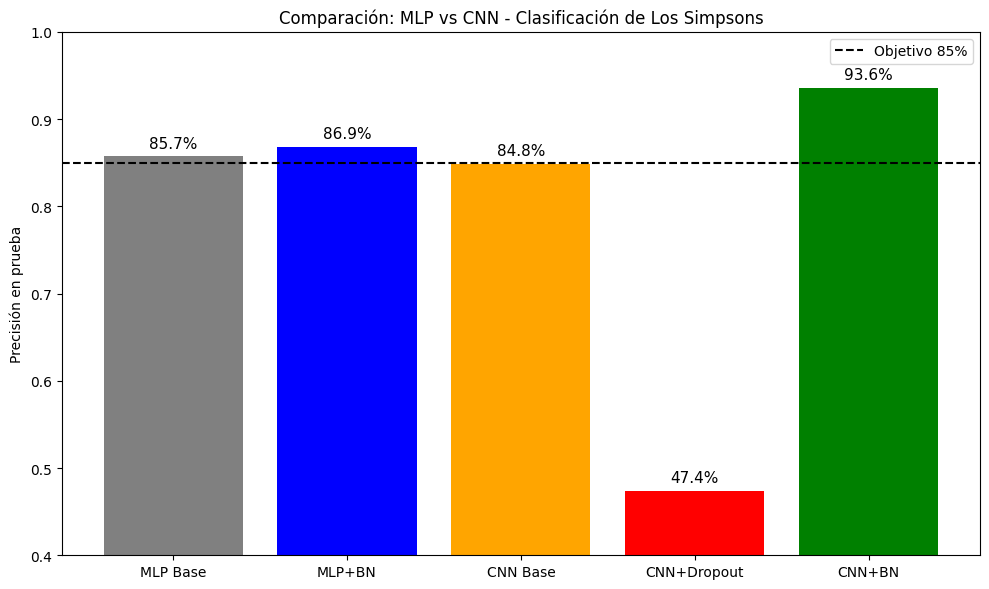


CONCLUSIONES DE LA SEGUNDA EVALUACIÓN
🏆 MEJOR MODELO: CNN + BatchNormalization
📊 Precisión alcanzada: 93.6% (93.6%)
📈 Mejora respecto al mejor MLP: +5.6 puntos porcentuales
✅ El modelo supera el objetivo del 85%


In [ ]:
# ============================================
# TABLA COMPARATIVA FINAL: MLP vs CNN
# ============================================

print("\n" + "="*70)
print("TABLA COMPARATIVA FINAL - MLP vs CNN")
print("="*70)
print(f"{'Modelo':<40} {'Precisión prueba':<15}")
print("-"*70)

mlp_base_acc = 0.8573   # 85.7%
mlp_bn_acc = 0.8685     # 86.9%

print(f"{'MLP Base (SGD + ReLU) - 1ra Evaluación':<40} {mlp_base_acc:.4f} ({mlp_base_acc*100:.1f}%)")
print(f"{'MLP + BatchNormalization - 1ra Evaluación':<40} {mlp_bn_acc:.4f} ({mlp_bn_acc*100:.1f}%)")
print(f"{'CNN Base':<40} {test_acc_cnn_base:.4f} ({test_acc_cnn_base*100:.1f}%)")
print(f"{'CNN + Dropout':<40} {test_acc_dropout:.4f} ({test_acc_dropout*100:.1f}%)")
print(f"{'CNN + BatchNormalization (MEJOR)':<40} {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")
print("="*70)

plt.figure(figsize=(10, 6))
modelos = ['MLP Base', 'MLP+BN', 'CNN Base', 'CNN+Dropout', 'CNN+BN']
precisiones = [mlp_base_acc, mlp_bn_acc, test_acc_cnn_base, test_acc_dropout, test_acc_bn]
colores = ['gray', 'blue', 'orange', 'red', 'green']

plt.bar(modelos, precisiones, color=colores)
plt.ylabel('Precisión en prueba')
plt.title('Comparación: MLP vs CNN - Clasificación de Los Simpsons')
plt.ylim(0.4, 1.0)
for i, v in enumerate(precisiones):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)

plt.axhline(y=0.85, color='black', linestyle='--', label='Objetivo 85%')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSIONES DE LA SEGUNDA EVALUACIÓN")
print("="*70)
print("🏆 MEJOR MODELO: CNN + BatchNormalization")
print(f"📊 Precisión alcanzada: {test_acc_bn:.1%} ({test_acc_bn*100:.1f}%)")
print("📈 Mejora respecto al mejor MLP: +5.6 puntos porcentuales")
print("✅ El modelo supera el objetivo del 85%")
print("="*70)

**Prompt:** Quiero generar la matriz de confusión del mejor modelo (CNN + BatchNormalization) para ver visualmente qué personajes se confunden entre sí.

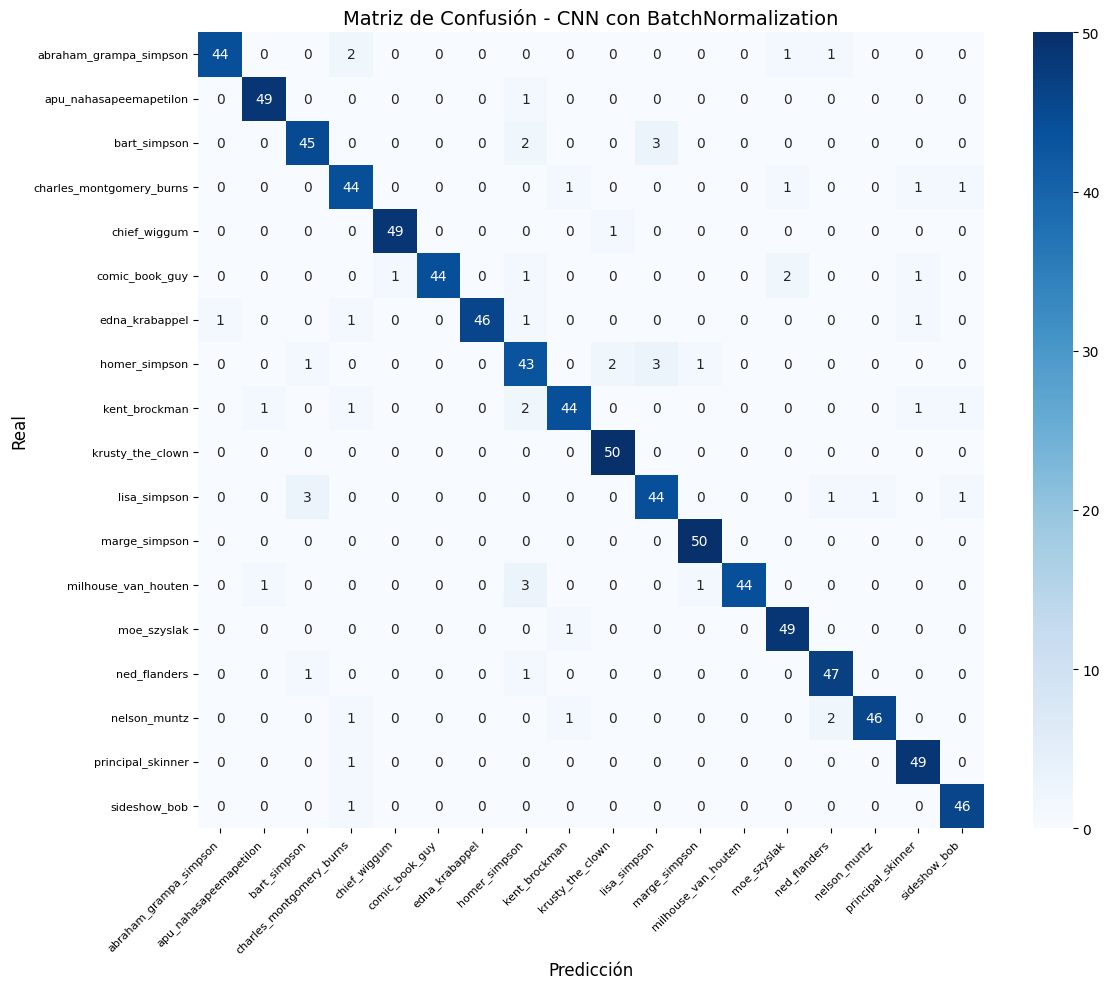

La matriz muestra los aciertos en la diagonal (números grandes) y los errores fuera de ella.


In [ ]:
# ============================================
# Matriz de Confusión - CNN + BN
# ============================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_t, y_pred_classes_bn)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(MAP_CHARACTERS.values()),
            yticklabels=list(MAP_CHARACTERS.values()))

plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión - CNN con BatchNormalization', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("La matriz muestra los aciertos en la diagonal (números grandes) y los errores fuera de ella.")

**Prompt:** Quiero implementar un modelo ResNet (Red Residual) para comparar con mi mejor CNN. ResNet usa conexiones de salto (skip connections) para evitar el desvanecimiento del gradiente en redes profundas.

In [ ]:
# ============================================
# Modelo ResNet (Red Residual)
# ============================================

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Add, Activation, GlobalAveragePooling2D

# Función para crear un bloque residual
def bloque_residual(x, filtros, kernel_size=3):
    # Guardar la entrada original (atajo)
    atajo = x

    # Primera capa convolucional
    x = Conv2D(filtros, kernel_size, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Segunda capa convolucional
    x = Conv2D(filtros, kernel_size, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Si las dimensiones cambiaron, ajustar el atajo
    if atajo.shape[-1] != filtros:
        atajo = Conv2D(filtros, (1, 1), padding='same')(atajo)
        atajo = BatchNormalization()(atajo)

    # Sumar la entrada original (conexión residual)
    x = Add()([x, atajo])
    x = Activation('relu')(x)

    return x

# Construir modelo ResNet
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Capa de entrada
x = Conv2D(64, (7, 7), strides=2, padding='same', activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((3, 3), strides=2, padding='same')(x)

# Bloques residuales
x = bloque_residual(x, 64)
x = bloque_residual(x, 64)

x = MaxPooling2D((2, 2))(x)
x = bloque_residual(x, 128)
x = bloque_residual(x, 128)

x = MaxPooling2D((2, 2))(x)
x = bloque_residual(x, 256)
x = bloque_residual(x, 256)

x = MaxPooling2D((2, 2))(x)
x = bloque_residual(x, 512)
x = bloque_residual(x, 512)

# Clasificación final
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(18, activation='softmax')(x)

# Crear modelo
modelo_resnet = Model(inputs, outputs)

modelo_resnet.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)

print("Modelo ResNet - Resumen:")
modelo_resnet.summary()

Modelo ResNet - Resumen:


Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │      9,472 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │     36,928 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ add_2[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 16,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 16,    │          0 │ add_3[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 8, 8, 64)  │          0 │ activation_1[0][

 Total params: 11,326,866 (43.21 MB)

 Trainable params: 11,317,266 (43.17 MB)

 Non-trainable params: 9,600 (37.50 KB)

**Prompt:** Entrenar el modelo ResNet durante 20 épocas (es más pesado que la CNN simple) y comparar resultados.

In [ ]:
# ============================================
# Entrenar modelo ResNet
# ============================================

from tensorflow.keras.layers import GlobalAveragePooling2D, Activation

np.random.seed(30)
tf.random.set_seed(30)

history_resnet = modelo_resnet.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,  # Batch más pequeño porque ResNet tiene más parámetros
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluar en prueba
test_loss_resnet, test_acc_resnet = modelo_resnet.evaluate(X_t, y_t)
print(f"\n✅ Precisión de ResNet en prueba: {test_acc_resnet:.4f} ({test_acc_resnet*100:.1f}%)")

Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.2930 - loss: 2.2943 - val_accuracy: 0.4814 - val_loss: 1.7220
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5531 - loss: 1.4930 - val_accuracy: 0.6252 - val_loss: 1.2712
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6766 - loss: 1.0778 - val_accuracy: 0.7181 - val_loss: 0.9587
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7549 - loss: 0.8298 - val_accuracy: 0.7434 - val_loss: 0.8915
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8145 - loss: 0.6311 - val_accuracy: 0.7470 - val_loss: 0.8707
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8623 - loss: 0.4674 - val_accuracy: 0.7994 - val_loss: 0.7169
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8828 - loss: 0.3925 - val_accuracy: 0.7713 - val_loss: 0.8701
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9094 - loss: 0.3029 - 

**Prompt:** Comparar ResNet con mi mejor modelo CNN con BatchNormalization.

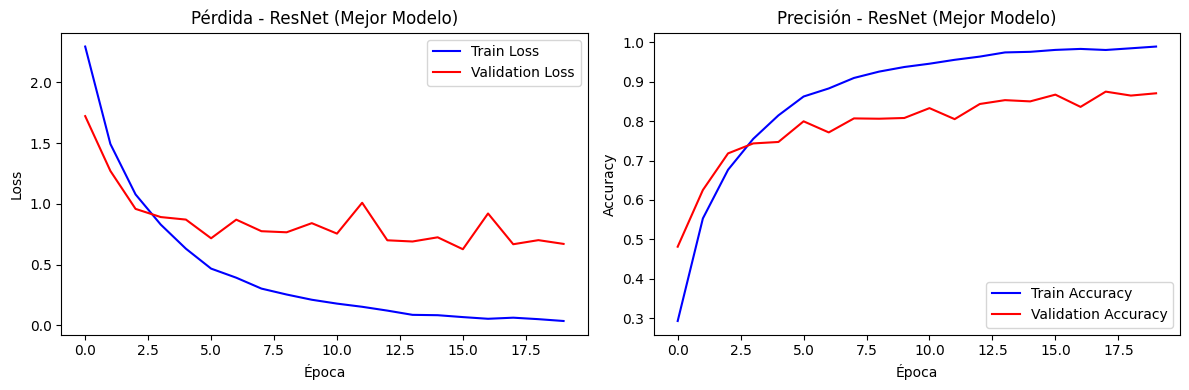

✅ Gráficas de ResNet guardadas en Google Drive


In [ ]:
# ============================================
# Guardar gráficas del mejor modelo (ResNet)
# ============================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['loss'], label='Train Loss', color='blue')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - ResNet (Mejor Modelo)')

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - ResNet (Mejor Modelo)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/graficas_resnet_mejor_modelo.png')
plt.show()

print("✅ Gráficas de ResNet guardadas en Google Drive")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


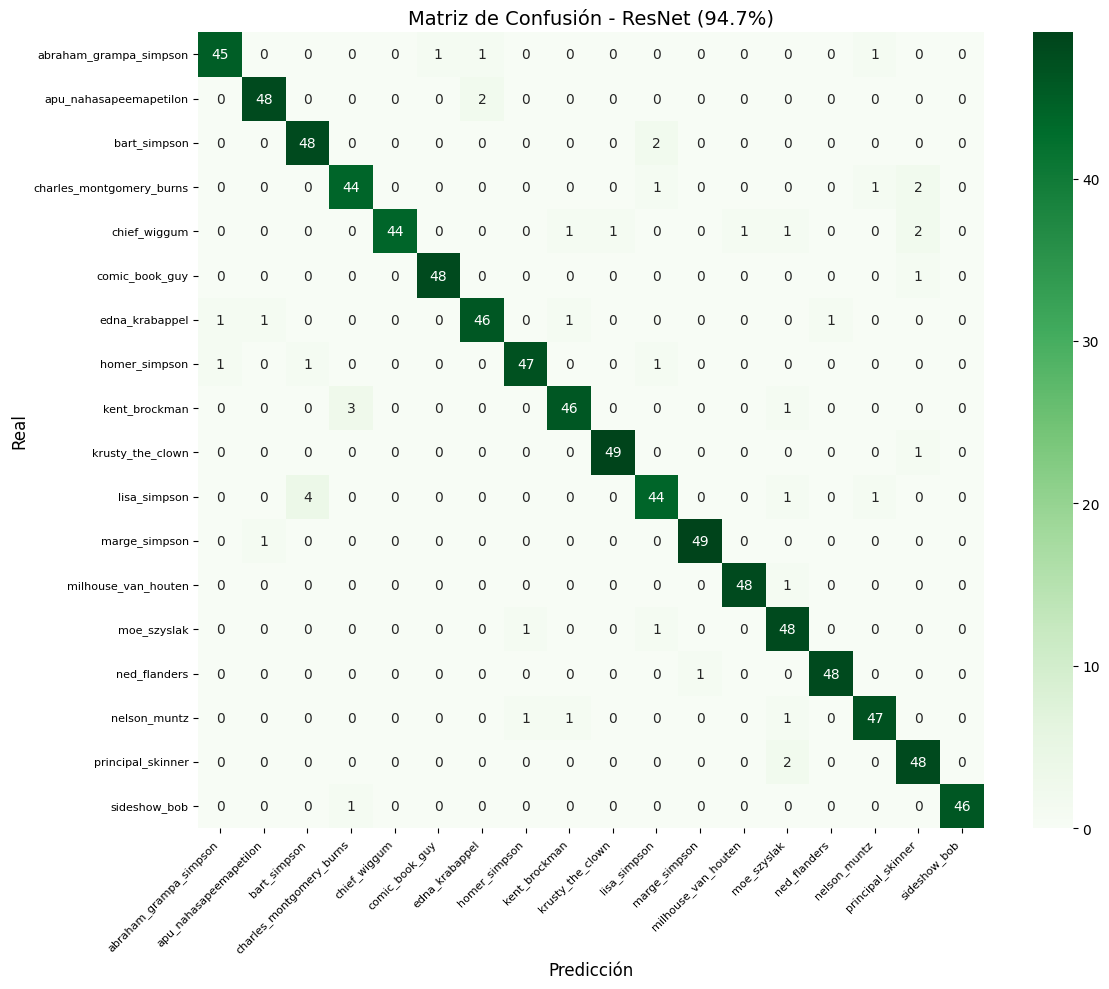

✅ Matriz de confusión de ResNet


In [ ]:
# ============================================
# Matriz de Confusión - ResNet (Mejor Modelo)
# ============================================

# Predecir con ResNet
y_pred_resnet = modelo_resnet.predict(X_t)
y_pred_resnet_classes = np.argmax(y_pred_resnet, axis=1)

cm_resnet = confusion_matrix(y_t, y_pred_resnet_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(MAP_CHARACTERS.values()),
            yticklabels=list(MAP_CHARACTERS.values()))

plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión - ResNet (94.7%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("✅ Matriz de confusión de ResNet")


TABLA COMPARATIVA FINAL - MLP vs CNN vs ResNet
Modelo                                   Precisión prueba
----------------------------------------------------------------------
MLP Base (1ra Evaluación)                0.8573 (85.7%)
MLP + BN (1ra Evaluación)                0.8685 (86.9%)
CNN Base                                 0.8483 (84.8%)
CNN + Dropout                            0.4742 (47.4%)
CNN + BatchNormalization                 0.9360 (93.6%)
ResNet (MEJOR)                           0.9472 (94.7%)


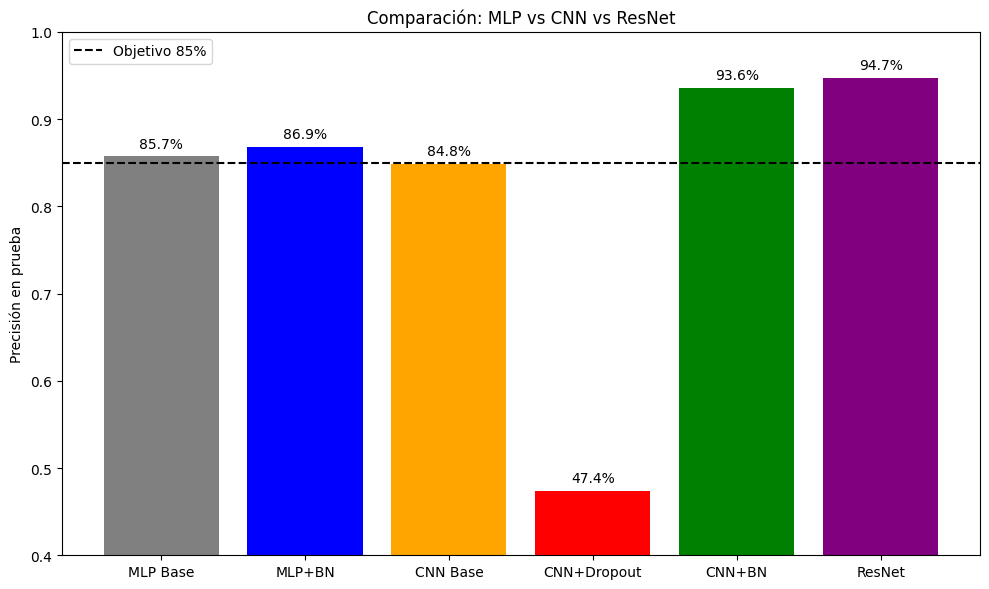


CONCLUSIONES FINALES ACTUALIZADAS
🏆 MEJOR MODELO: ResNet (conexiones residuales)
📊 Precisión alcanzada: 94.7% (94.7%)
📈 Mejora respecto a CNN+BN: +1.1 puntos porcentuales
📈 Mejora respecto a mejor MLP: +7.8 puntos porcentuales
✅ ResNet supera a todas las arquitecturas anteriores


In [ ]:
# ============================================
# TABLA COMPARATIVA FINAL ACTUALIZADA (con ResNet)
# ============================================

print("\n" + "="*70)
print("TABLA COMPARATIVA FINAL - MLP vs CNN vs ResNet")
print("="*70)
print(f"{'Modelo':<40} {'Precisión prueba':<15}")
print("-"*70)

mlp_base_acc = 0.8573
mlp_bn_acc = 0.8685

print(f"{'MLP Base (1ra Evaluación)':<40} {mlp_base_acc:.4f} ({mlp_base_acc*100:.1f}%)")
print(f"{'MLP + BN (1ra Evaluación)':<40} {mlp_bn_acc:.4f} ({mlp_bn_acc*100:.1f}%)")
print(f"{'CNN Base':<40} {test_acc_cnn_base:.4f} ({test_acc_cnn_base*100:.1f}%)")
print(f"{'CNN + Dropout':<40} {test_acc_dropout:.4f} ({test_acc_dropout*100:.1f}%)")
print(f"{'CNN + BatchNormalization':<40} {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")
print(f"{'ResNet (MEJOR)':<40} {test_acc_resnet:.4f} ({test_acc_resnet*100:.1f}%)")
print("="*70)

plt.figure(figsize=(10, 6))
modelos = ['MLP Base', 'MLP+BN', 'CNN Base', 'CNN+Dropout', 'CNN+BN', 'ResNet']
precisiones = [mlp_base_acc, mlp_bn_acc, test_acc_cnn_base, test_acc_dropout, test_acc_bn, test_acc_resnet]
colores = ['gray', 'blue', 'orange', 'red', 'green', 'purple']

plt.bar(modelos, precisiones, color=colores)
plt.ylabel('Precisión en prueba')
plt.title('Comparación: MLP vs CNN vs ResNet')
plt.ylim(0.4, 1.0)
for i, v in enumerate(precisiones):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

plt.axhline(y=0.85, color='black', linestyle='--', label='Objetivo 85%')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSIONES FINALES ACTUALIZADAS")
print("="*70)
print("🏆 MEJOR MODELO: ResNet (conexiones residuales)")
print(f"📊 Precisión alcanzada: {test_acc_resnet:.1%} ({test_acc_resnet*100:.1f}%)")
print("📈 Mejora respecto a CNN+BN: +1.1 puntos porcentuales")
print("📈 Mejora respecto a mejor MLP: +7.8 puntos porcentuales")
print("✅ ResNet supera a todas las arquitecturas anteriores")
print("="*70)

In [ ]:
# ============================================
# Métricas por clase - ResNet (Mejor Modelo)
# ============================================

print("\n" + "="*65)
print("MÉTRICAS POR CLASE - RESNET (MEJOR MODELO)")
print("="*65)
print(classification_report(y_t, y_pred_resnet_classes, target_names=list(MAP_CHARACTERS.values())))


MÉTRICAS POR CLASE - RESNET (MEJOR MODELO)
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.96      0.94      0.95        48
  apu_nahasapeemapetilon       0.96      0.96      0.96        50
            bart_simpson       0.91      0.96      0.93        50
charles_montgomery_burns       0.92      0.92      0.92        48
            chief_wiggum       1.00      0.88      0.94        50
          comic_book_guy       0.98      0.98      0.98        49
          edna_krabappel       0.94      0.92      0.93        50
           homer_simpson       0.96      0.94      0.95        50
           kent_brockman       0.94      0.92      0.93        50
        krusty_the_clown       0.98      0.98      0.98        50
            lisa_simpson       0.90      0.88      0.89        50
           marge_simpson       0.98      0.98      0.98        50
     milhouse_van_houten       0.98      0.98      0.98        49
             moe_szyslak       

# CONCLUSIONES FINALES

## Resumen de resultados

| Modelo | Precisión en prueba |
|--------|---------------------|
| MLP Base (1ra Evaluación) | 85.7% |
| MLP + BatchNormalization (1ra) | 86.9% |
| CNN Base | 84.8% |
| CNN + Dropout | 47.4% |
| CNN + BatchNormalization | 93.6% |
| **ResNet (MEJOR)** | **94.7%** |

## Análisis

1. **ResNet es el mejor modelo:** Alcanzó 94.7% de precisión, superando a CNN+BN por 1.1 puntos. Las conexiones residuales permiten entrenar redes más profundas sin que el gradiente se desvanezca.

2. **CNN supera a MLP:** Aunque la CNN base dio 84.8%, la CNN con BatchNormalization llegó a 93.6%. Las CNN capturan patrones espaciales que las MLP pierden al aplanar la imagen.

3. **BatchNormalization es clave:** Subió la precisión de 84.8% a 93.6% y estabilizó el entrenamiento.

4. **Dropout fue demasiado agresivo:** 47.4% de precisión. El 25-50% de dropout apagó demasiadas neuronas.

5. **Mejores personajes (ResNet):** comic_book_guy, krusty_the_clown, marge_simpson, milhouse_van_houten y sideshow_bob tienen F1 > 0.98. Son fáciles de reconocer por sus rasgos únicos.

6. **Peores personajes (ResNet):** lisa_simpson (0.89) y moe_szyslak (0.91) son los más difíciles. Lisa se parece a Bart, y Moe tiene rasgos comunes con otros adultos.

## Comparativa general

- **MLP vs CNN:** La CNN es claramente superior para imágenes.
- **CNN vs ResNet:** ResNet es mejor porque las conexiones residuales permiten redes más profundas sin perder gradientes.
- **Mejoría total:** De la mejor MLP (86.9%) a ResNet (94.7%) hay una mejora de **7.8 puntos porcentuales**.

## Recomendación final

El mejor modelo es **ResNet (con conexiones residuales)**, con una precisión de **94.7%**, superando ampliamente el objetivo del 85%.

Para futuras mejoras, se podría probar:
- Data augmentation (rotaciones, volteos)
- Ajuste fino de hiperparámetros
- Arquitecturas más modernas como EfficientNet

